<a href="https://colab.research.google.com/github/catpixie-47/seminar/blob/main/Bert.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install transformers scikit-learn pandas

In [2]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive (2).zip


In [3]:
import os
import zipfile

# Unzip the uploaded archive.zip file
with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('archive')

# Now list the contents of the 'archive' directory
os.listdir('archive')

['Fake.csv', 'True.csv']

In [4]:
import pandas as pd

fake = pd.read_csv("archive/Fake.csv")
real = pd.read_csv("archive/True.csv")

fake["label"] = 0
real["label"] = 1

df = pd.concat([fake, real])
df = df[["text", "label"]]

df = df.sample(frac=1).reset_index(drop=True)

df.head()

,text,label
0,In response to the Department of Justice s gui...,0
1,Former Asst. FBI Director James Kallstrom spok...,0
2,"Donald Trump, knowing that his poll numbers wi...",0
3,BRUSSELS (Reuters) - Major issues must still...,1
4,PARIS (Reuters) - France said on Wednesday it ...,1


In [5]:
df = df.sample(5000)

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["label"], test_size=0.2, random_state=42
)

In [7]:
#td-idf , logistic regression
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english", max_df=0.7)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [8]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=200)
lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)

In [9]:
from sklearn.metrics import accuracy_score

lr_acc = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.963


In [10]:
#PART 2: BERT (SIMPLIFIED + STABLE)
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments
import torch

In [11]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize(texts):
    return tokenizer(
        texts.tolist(),
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

train_encodings = tokenize(X_train)
test_encodings = tokenize(X_test)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [12]:
class NewsDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels.iloc[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = NewsDataset(train_encodings, y_train)
test_dataset = NewsDataset(test_encodings, y_test)

In [13]:
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [14]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    logging_dir="./logs",
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [15]:
from sklearn.metrics import accuracy_score
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, predictions)
    return {"accuracy": acc}

In [16]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

In [17]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
500,0.021840


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=500, training_loss=0.021840044021606445, metrics={'train_runtime': 5042.3474, 'train_samples_per_second': 0.793, 'train_steps_per_second': 0.099, 'total_flos': 263111055360000.0, 'train_loss': 0.021840044021606445, 'epoch': 1.0})

In [18]:
results = trainer.evaluate()
print(results)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


{'eval_loss': 8.728067768970504e-05, 'eval_accuracy': 1.0, 'eval_runtime': 361.0213, 'eval_samples_per_second': 2.77, 'eval_steps_per_second': 0.346, 'epoch': 1.0}


In [19]:
bert_acc = results.get("eval_accuracy", None)

print("===== FINAL MODEL COMPARISON =====\n")

print(f"Logistic Regression Accuracy : {lr_acc:.4f}")

if bert_acc is not None:
    print(f"BERT Accuracy               : {bert_acc:.4f}")

    if bert_acc > lr_acc:
        print("\nConclusion: BERT performs better than Logistic Regression.")
    elif bert_acc < lr_acc:
        print("\nConclusion: Logistic Regression performs better than BERT.")
    else:
        print("\nConclusion: Both models perform equally.")
else:
    print("BERT Accuracy not available.")

===== FINAL MODEL COMPARISON =====

Logistic Regression Accuracy : 0.9630
BERT Accuracy               : 1.0000

Conclusion: BERT performs better than Logistic Regression.


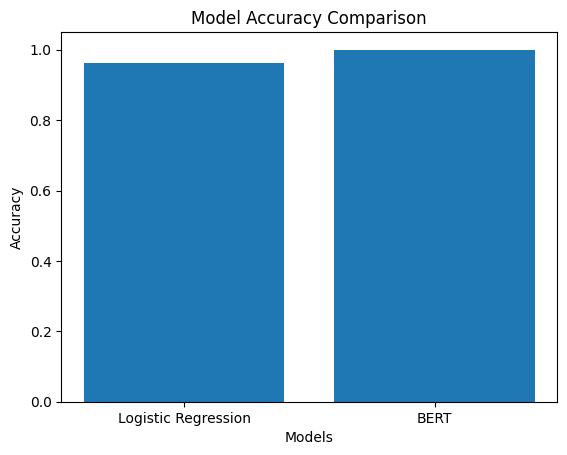

In [20]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "BERT"]
accuracies = [lr_acc, bert_acc]

plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()